# Bias, Variance & Regularization
*Data 200 · Applied Statistical Analysis · Instructor: Aayush Regmi*

---

In the [Parameter Estimation notebook](ParameterEstimation.md) we learned
*how* a model finds its parameters — through OLS, Gradient Descent, or
MLE. This notebook is about the next question every data scientist hits:

> **My model fits the training data — but should it?**

Sometimes the answer is no, because the model is *memorising the noise*
instead of learning the pattern. We will look at why this happens (the
**bias-variance tradeoff**), what it looks like (**overfitting**), and
the standard tool for taming it (**regularization** — Ridge, Lasso, and
Elastic Net).


## Learning Objectives

By the end of this notebook you should be able to:

1. Explain **bias**, **variance**, and **irreducible noise** in plain
   words and write down the error decomposition.
2. Recognise the **classic train-vs-test U-curve** as a model gets more
   complex.
3. Describe what **regularization** does mathematically — adding a
   penalty to the loss — and why it produces smoother fits.
4. Compare **L1 (Lasso)**, **L2 (Ridge)**, and **Elastic Net**
   penalties and say when each is appropriate.
5. Derive the **gradient of the Ridge loss** and run a hand-rolled
   gradient-descent loop to optimise it.
6. Pick a sensible **regularisation strength $\alpha$** with
   cross-validation.


## Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV,
)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
rng = np.random.default_rng(0)


## 1. Why a Model Goes Wrong — Bias, Variance, Noise

Every prediction error a model makes can be split into three
ingredients:

- **Bias** — the model is *systematically* wrong because it is too
  simple to capture the true pattern. A straight line trying to fit a
  curve has high bias.
- **Variance** — the model is *too sensitive* to the particular
  training sample it saw. Train it on a slightly different sample and
  the fit changes dramatically. A high-degree polynomial has high
  variance.
- **Noise** — the part of the data we cannot explain no matter how
  good the model is. Measurement error, randomness, things our features
  don't see. This is sometimes called **irreducible error**.

These three combine in the famous **error decomposition**:

$$\boxed{\;
\mathbb{E}[\text{prediction error}^2] \;=\;
\underbrace{\text{bias}^2}_{\text{too simple}} \;+\;
\underbrace{\text{variance}}_{\text{too sensitive}} \;+\;
\underbrace{\sigma^2}_{\text{noise — unfixable}}\;}$$

Bias and variance pull in opposite directions — that's the **tradeoff**.


### Seeing variance with our own eyes

If "variance" means *how much would my fit change if I had a different
training sample?*, the easiest way to see it is to **resample the
training data many times and re-fit each time**. The spread of the
resulting curves *is* the variance.

Below we do exactly that for two models on the same noisy sin-curve:
a degree-1 line (high bias, low variance) and a degree-15 polynomial
(low bias, high variance).


/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-package

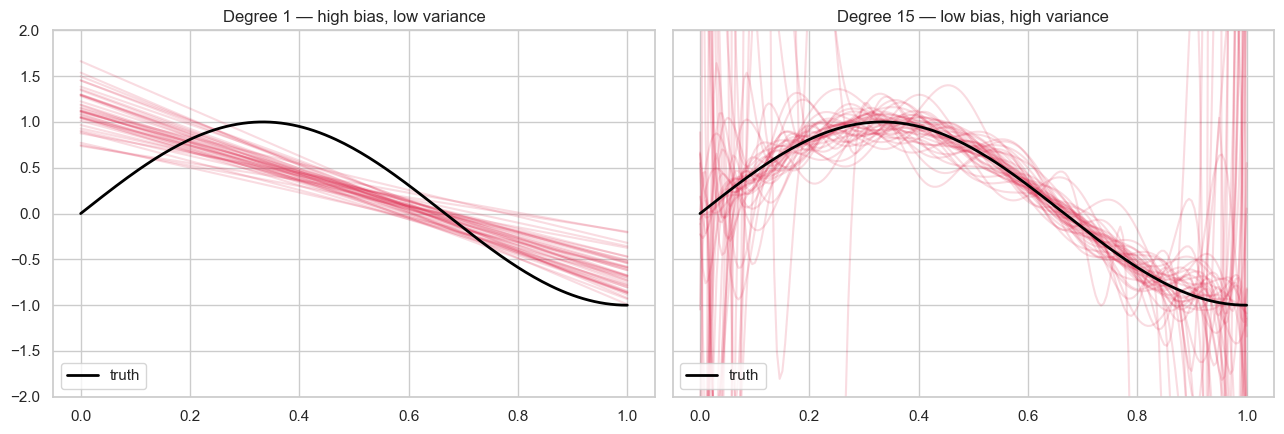

In [12]:
def true_f(x):
    return np.sin(1.5 * np.pi * x)

x_grid = np.linspace(0, 1, 200)
n_samples = 30
n_resamples = 40

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, deg, title in zip(
    axes,
    [1, 15],
    ["Degree 1 — high bias, low variance",
     "Degree 15 — low bias, high variance"],
):
    for _ in range(n_resamples):
        x = rng.uniform(0, 1, n_samples)
        y = true_f(x) + rng.normal(scale=0.15, size=n_samples)
        model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
        model.fit(x.reshape(-1, 1), y)
        ax.plot(x_grid, model.predict(x_grid.reshape(-1, 1)),
                color="crimson", alpha=0.15)
    ax.plot(x_grid, true_f(x_grid), color="black", lw=2, label="truth")
    ax.set_ylim(-2, 2)
    ax.set_title(title)
    ax.legend(loc="lower left")

plt.tight_layout(); plt.show()


**Read the picture:**

- Left: every red line is almost the same — the model is so rigid it
  gives basically the same answer no matter which sample it sees.
  Low variance, but the line is far from the truth — high bias.
- Right: the red lines are wildly different from one another — the
  fit is *extremely* sensitive to which 30 points it happens to see.
  Low bias on average, but huge variance.

The job of regularization is to **drag the right-hand picture toward a
tighter, calmer family of curves**, accepting a tiny bit of bias in
exchange for a big drop in variance.


## 2. Overfitting in Pictures

Let's now look at a single training set and increase the model's
complexity, watching both the **training error** and the **test
error** as we go. This is the canonical "U-shape" curve — the
fingerprint of overfitting.


/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-package

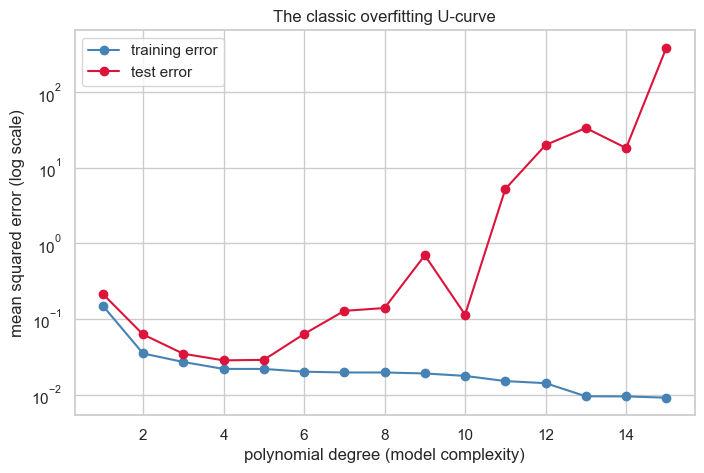

In [13]:
n_train, n_test = 30, 200
x_train = np.sort(rng.uniform(0, 1, n_train))
y_train = true_f(x_train) + rng.normal(scale=0.15, size=n_train)
x_test  = np.sort(rng.uniform(0, 1, n_test))
y_test  = true_f(x_test)  + rng.normal(scale=0.15, size=n_test)

degrees = list(range(1, 16))
train_err, test_err = [], []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression())
    m.fit(x_train.reshape(-1, 1), y_train)
    train_err.append(mean_squared_error(y_train, m.predict(x_train.reshape(-1, 1))))
    test_err .append(mean_squared_error(y_test , m.predict(x_test .reshape(-1, 1))))

plt.plot(degrees, train_err, marker="o", color="steelblue", label="training error")
plt.plot(degrees, test_err , marker="o", color="crimson",  label="test error")
plt.yscale("log")
plt.xlabel("polynomial degree (model complexity)")
plt.ylabel("mean squared error (log scale)")
plt.title("The classic overfitting U-curve")
plt.legend(); plt.show()


Read the curves:

- **Training error** keeps falling — a more flexible model can always
  fit the training points better.
- **Test error** falls at first (we're escaping high bias), reaches a
  minimum (the *sweet spot*), then climbs again as the model starts
  fitting noise instead of signal (variance takes over).

The minimum of the red curve is the model we actually want.
Regularization is one of the cleanest tools for sliding *along* this
curve without having to change the model's shape.


## 3. What Regularization Does — Mathematically, but Gently

Plain OLS picks coefficients $\boldsymbol\beta$ to minimise the **data
loss**:

$$L_{\text{data}}(\boldsymbol\beta) \;=\; \sum_{i=1}^n (y_i - \hat y_i)^2.$$

Regularization adds a **penalty** that gets bigger when the
coefficients themselves get bigger:

$$\boxed{\;
L_{\text{new}}(\boldsymbol\beta) \;=\;
\underbrace{L_{\text{data}}(\boldsymbol\beta)}_{\text{fit the data}}
\;+\;
\alpha \cdot \underbrace{R(\boldsymbol\beta)}_{\text{punish big coefficients}}\;
}$$

- $R(\boldsymbol\beta)$ is the **penalty function**. Different choices
  give different regularizers (L1, L2, Elastic Net).
- $\alpha \geq 0$ is the **strength**. $\alpha = 0$ recovers plain OLS;
  $\alpha \to \infty$ forces every coefficient to zero.

Why does this produce *smoother* fits? Wild, overfit curves need
**large coefficients** to do their wiggling. By making the optimizer
pay a price for large coefficients, we steer it toward flatter,
calmer fits — at the cost of a small amount of bias.


### The geometric picture

The picture below is one of the most useful in all of ML. The
**ellipses** are contours of the OLS loss (concentric ovals around the
OLS solution $\hat{\boldsymbol\beta}$). The **shaded region** is the
set of coefficients allowed by the penalty — a circle for L2, a
diamond for L1.

The regularised solution is the point where the smallest possible
ellipse first **touches** the allowed region.


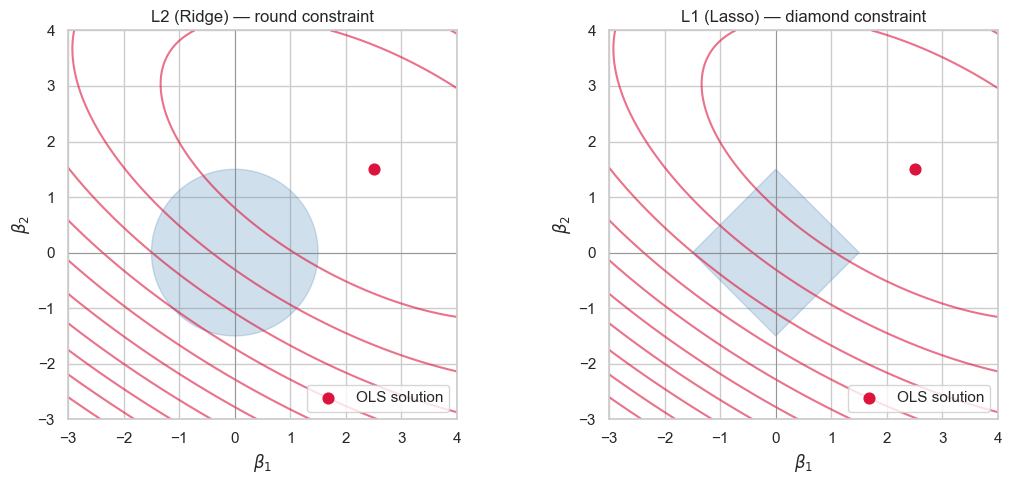

In [14]:
beta_star = np.array([2.5, 1.5])     # pretend OLS solution
g = np.linspace(-3, 4, 400)
B1, B2 = np.meshgrid(g, g)
L = (B1 - beta_star[0]) ** 2 + 1.6 * (B1 - beta_star[0]) * (B2 - beta_star[1]) \
    + 2 * (B2 - beta_star[1]) ** 2

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, shape, title in zip(
    axes,
    ["circle", "diamond"],
    ["L2 (Ridge) — round constraint", "L1 (Lasso) — diamond constraint"],
):
    ax.contour(B1, B2, L, levels=12, colors="crimson", alpha=0.6)
    ax.scatter(*beta_star, color="crimson", zorder=5, s=60, label="OLS solution")
    theta = np.linspace(0, 2 * np.pi, 200)
    if shape == "circle":
        r = 1.5
        ax.fill(r * np.cos(theta), r * np.sin(theta), color="steelblue", alpha=0.25)
    else:
        r = 1.5
        d_x = r * np.array([1, 0, -1, 0, 1])
        d_y = r * np.array([0, 1, 0, -1, 0])
        ax.fill(d_x, d_y, color="steelblue", alpha=0.25)
    ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlim(-3, 4); ax.set_ylim(-3, 4); ax.set_aspect("equal")
    ax.set_xlabel(r"$\beta_1$"); ax.set_ylabel(r"$\beta_2$")
    ax.set_title(title); ax.legend(loc="lower right")

plt.tight_layout(); plt.show()


Notice the diamond's **corners** sit on the axes. The smallest
ellipse will *almost always* touch the diamond at one of those
corners — and a corner means **one of the coefficients is exactly
zero**. That is the geometric reason **Lasso does feature selection**
and Ridge does not.


## 4. Ridge (L2) Regularization

Ridge uses the **squared** penalty:

$$R_{\text{Ridge}}(\boldsymbol\beta) \;=\; \sum_j \beta_j^2,
\qquad
L_{\text{Ridge}} \;=\; \sum_i (y_i - \hat y_i)^2 \;+\; \alpha \sum_j \beta_j^2.$$

Squaring means **bigger coefficients get punished disproportionately
more**. The result: Ridge **shrinks all coefficients toward zero, but
almost never lands exactly on zero**. Use Ridge when you believe most
features matter a little.


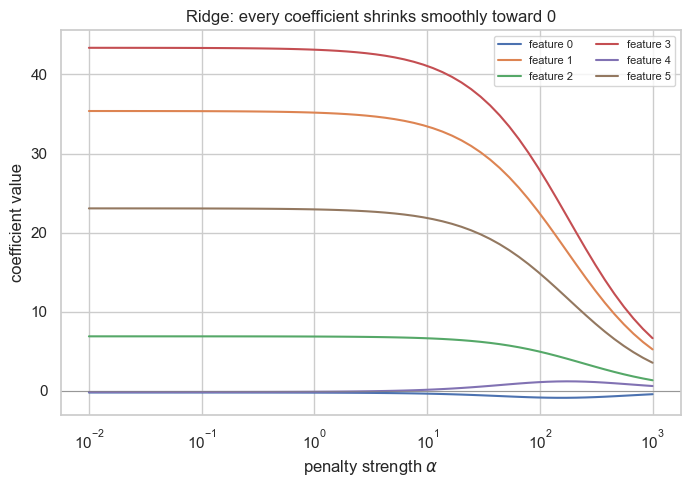

In [15]:
from sklearn.datasets import make_regression
X_r, y_r = make_regression(
    n_samples=200, n_features=6, n_informative=4,
    noise=8, random_state=0,
)

alphas = np.logspace(-2, 3, 60)
ridge_path = np.array([Ridge(alpha=a).fit(X_r, y_r).coef_ for a in alphas])

plt.figure(figsize=(8, 5))
for j in range(ridge_path.shape[1]):
    plt.plot(alphas, ridge_path[:, j], label=f"feature {j}")
plt.xscale("log")
plt.xlabel(r"penalty strength $\alpha$")
plt.ylabel("coefficient value")
plt.title("Ridge: every coefficient shrinks smoothly toward 0")
plt.axhline(0, color="gray", lw=0.5)
plt.legend(fontsize=8, ncol=2); plt.show()


## 5. Lasso (L1) Regularization

Lasso uses the **absolute-value** penalty:

$$R_{\text{Lasso}}(\boldsymbol\beta) \;=\; \sum_j |\beta_j|,
\qquad
L_{\text{Lasso}} \;=\; \sum_i (y_i - \hat y_i)^2 \;+\; \alpha \sum_j |\beta_j|.$$

Because of the diamond geometry from §3, Lasso doesn't merely shrink
coefficients — it **snaps them to exactly zero** one by one as $\alpha$
grows. So Lasso doubles as an **automatic feature selector**: features
with a zero coefficient have been dropped from the model.


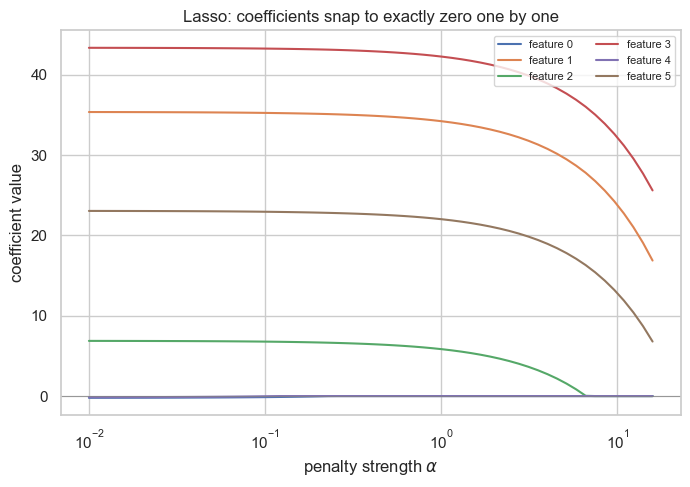

In [16]:
alphas_l = np.logspace(-2, 1.2, 60)
lasso_path = np.array([
    Lasso(alpha=a, max_iter=20000).fit(X_r, y_r).coef_ for a in alphas_l
])

plt.figure(figsize=(8, 5))
for j in range(lasso_path.shape[1]):
    plt.plot(alphas_l, lasso_path[:, j], label=f"feature {j}")
plt.xscale("log")
plt.xlabel(r"penalty strength $\alpha$")
plt.ylabel("coefficient value")
plt.title("Lasso: coefficients snap to exactly zero one by one")
plt.axhline(0, color="gray", lw=0.5)
plt.legend(fontsize=8, ncol=2); plt.show()


## 6. Elastic Net — Mixing the Two

**Elastic Net** is just a weighted blend of L1 and L2:

$$R_{\text{EN}}(\boldsymbol\beta) \;=\;
\rho \sum_j |\beta_j| \;+\; \frac{1-\rho}{2} \sum_j \beta_j^2.$$

The mixing parameter $\rho \in [0, 1]$ slides between Lasso
($\rho = 1$) and Ridge ($\rho = 0$).

Reach for Elastic Net when:

- you have **lots of features** but **groups of correlated ones**
  (Lasso alone tends to keep just one from each group somewhat
  arbitrarily; Elastic Net keeps the group together while still doing
  some selection).
- you want **some shrinkage** *and* **some feature dropping**.


In [17]:
alpha_en = 0.5
for rho in [0.0, 0.5, 1.0]:
    if rho == 0.0:
        m = Ridge(alpha=alpha_en).fit(X_r, y_r)
        label = "ρ=0 (pure Ridge)"
    elif rho == 1.0:
        m = Lasso(alpha=alpha_en, max_iter=20000).fit(X_r, y_r)
        label = "ρ=1 (pure Lasso)"
    else:
        m = ElasticNet(alpha=alpha_en, l1_ratio=rho, max_iter=20000).fit(X_r, y_r)
        label = f"ρ={rho} (Elastic Net)"
    print(f"{label:<22}  coefficients = {np.round(m.coef_, 2)}")


ρ=0 (pure Ridge)        coefficients = [-0.23 35.28  6.87 43.26 -0.14 23.  ]
ρ=0.5 (Elastic Net)     coefficients = [-0.5  27.22  5.56 33.73  0.56 17.85]
ρ=1 (pure Lasso)        coefficients = [-0.   34.8   6.36 42.83 -0.   22.54]


## 7. Optimizing a Regularised Loss

Let's actually *solve* for the Ridge coefficients with hand-rolled
gradient descent — to make the abstract formulas concrete.

### The Ridge gradient

The Ridge loss in matrix form is

$$L_{\text{Ridge}}(\boldsymbol\beta) \;=\;
\|y - X\boldsymbol\beta\|^2 \;+\; \alpha \|\boldsymbol\beta\|^2.$$

Take the gradient with respect to $\boldsymbol\beta$:

$$\nabla L_{\text{Ridge}}(\boldsymbol\beta) \;=\;
\underbrace{-2 X^\top (y - X\boldsymbol\beta)}_{\text{plain OLS gradient}}
\;+\; \underbrace{2 \alpha\, \boldsymbol\beta}_{\text{the regulariser's contribution}}.$$

**The Ridge gradient is just the OLS gradient plus a small pull toward
zero.** That is the *only* difference. We can plug it straight into the
same gradient-descent update we used in the Parameter Estimation
notebook.


In [18]:
# Build a small, slightly noisy linear problem with 4 features
n, p = 100, 4
X = rng.normal(size=(n, p))
true_beta = np.array([3.0, -2.0, 0.5, 0.0])
y = X @ true_beta + rng.normal(scale=1.0, size=n)

def ridge_gd(X, y, alpha=1.0, lr=0.005, n_iter=400):
    beta = np.zeros(X.shape[1])
    history = [beta.copy()]
    for _ in range(n_iter):
        grad = -2 * X.T @ (y - X @ beta) + 2 * alpha * beta
        beta = beta - lr * grad
        history.append(beta.copy())
    return beta, np.array(history)

beta_hat, hist = ridge_gd(X, y, alpha=5.0, lr=0.005, n_iter=400)

print(f"True coefficients : {true_beta}")
print(f"Ridge GD estimate : {np.round(beta_hat, 3)}")
print(f"sklearn Ridge     : {np.round(Ridge(alpha=5.0, fit_intercept=False).fit(X, y).coef_, 3)}")


True coefficients : [ 3.  -2.   0.5  0. ]
Ridge GD estimate : [ 2.966 -1.868  0.55   0.014]
sklearn Ridge     : [ 2.966 -1.868  0.55   0.014]


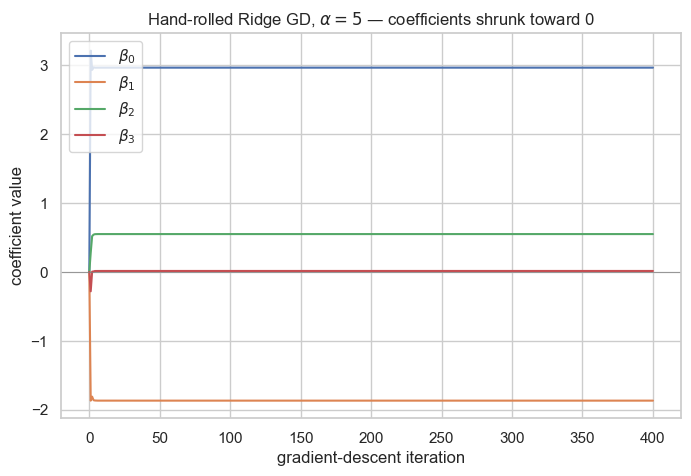

In [19]:
# Plot the trajectory of each coefficient as GD descends
for j in range(p):
    plt.plot(hist[:, j], label=fr"$\beta_{j}$")
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("gradient-descent iteration")
plt.ylabel("coefficient value")
plt.title(r"Hand-rolled Ridge GD, $\alpha=5$ — coefficients shrunk toward 0")
plt.legend(); plt.show()


Two things to notice:

1. The hand-rolled estimate matches what `sklearn.Ridge` returns — we
   really did just implement Ridge from scratch with one extra term in
   the gradient.
2. Every coefficient is **smaller in magnitude than the true value**.
   That bias toward zero is exactly the deal Ridge offers: a bit of
   bias in exchange for a lot less variance.

### What about Lasso?

The Lasso penalty $\sum_j |\beta_j|$ is **not differentiable at
$\beta_j = 0$** — the absolute value has a corner there. Ordinary
gradient descent doesn't quite work. The standard fixes are
**subgradient methods** or **coordinate descent**. The intuition is the
same — walk downhill on the loss — but the exact step rule has to
handle the corner. We'll happily let `sklearn.Lasso` do that for us.


## 8. Picking $\alpha$ — Cross-Validation in One Minute

$\alpha$ is a **hyperparameter** — it isn't learned from the training
data the way $\boldsymbol\beta$ is. The standard recipe is **k-fold
cross-validation**:

1. Split the training data into $k$ equal-sized **folds**.
2. For each candidate $\alpha$, train on $k-1$ folds and score on the
   held-out fold. Repeat for all $k$ choices of held-out fold and
   average.
3. Pick the $\alpha$ with the best average score.

scikit-learn ships with `RidgeCV` and `LassoCV` that do this for you:


In [20]:
alphas_cv = np.logspace(-3, 3, 80)

ridge_cv = RidgeCV(alphas=alphas_cv, cv=5).fit(X_r, y_r)
lasso_cv = LassoCV(alphas=alphas_cv, cv=5, max_iter=20000).fit(X_r, y_r)

print(f"RidgeCV picked alpha = {ridge_cv.alpha_:.4f}")
print(f"LassoCV picked alpha = {lasso_cv.alpha_:.4f}")


RidgeCV picked alpha = 0.2694
LassoCV picked alpha = 0.1594


## 9. Key Takeaways

1. Prediction error breaks into **bias² + variance + noise**. The
   first two are under your control; the third is not.
2. **Overfitting** is the symptom: training error keeps falling while
   test error starts rising. The classic U-curve.
3. **Regularization** adds a penalty $\alpha R(\boldsymbol\beta)$ to
   the loss so the optimizer prefers smaller, calmer coefficients —
   trading a little bias for a lot less variance.
4. **Ridge (L2)** shrinks coefficients smoothly. **Lasso (L1)** snaps
   them to zero, giving you feature selection for free.
   **Elastic Net** blends both.
5. The gradient of the Ridge loss is the OLS gradient **plus**
   $2\alpha\boldsymbol\beta$. Lasso needs a slightly fancier optimizer
   because of the corner at zero.
6. Pick $\alpha$ with **cross-validation** — `RidgeCV` and `LassoCV`
   are one-liners.


## 10. Practice Exercises

1. **Bias-variance demo extension.** Re-run the resampling experiment
   in §1 with degree 4 instead of 1 or 15. Where does it sit on the
   bias-variance spectrum? Sketch the new picture in words.
2. **Hand-rolled Ridge sweep.** Using the `ridge_gd` function from §7,
   sweep $\alpha \in \{0, 0.1, 1, 10, 100\}$ on the same data. Plot
   each coefficient's final value as a function of $\alpha$ and
   confirm the Ridge shrinkage pattern.
3. **Ridge vs. Lasso vs. Elastic Net.** Take the `make_regression`
   dataset from §4, fit all three with their `*CV` versions, and
   compare: which features survive in each? Which gives the best
   cross-validated score?
